In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
sys.path.append(str(root / "src"))

In [2]:
import math
import time

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from utils import repo_root

ROOT = repo_root()

```
x_s = (1-s)·x_0 + s·ε,     s in [0,1],  s=0 is data, s=1 is noise
```


In [3]:
T = 1000  # a unit for t, not a step count -- nothing is discretized yet


def s_of(t):
    return t / T


# diffusion needed betas -> alphas -> cumprod -> two sqrt tables.
# flow matching needs the line above.
s_of(torch.linspace(0, T, 6))

tensor([0.0000, 0.2000, 0.4000, 0.6000, 0.8000, 1.0000])

In [4]:
dataset = datasets.MNIST(
    root=ROOT / "data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    ),
)
x0, label = dataset[0]
print(label, x0.shape, x0.min().item(), x0.max().item())

5 torch.Size([1, 28, 28]) -1.0 1.0


In [5]:
def q_sample(x0, t, noise):
    s = s_of(t)
    return (1 - s) * x0 + s * noise


eps = torch.randn_like(x0)
# exact at both ends. diffusion only got x_T ~= eps (alphas_cumprod[-1] = 4e-5)
print("s=0 is data: ", torch.equal(q_sample(x0, 0.0, eps), x0))
print("s=1 is noise:", torch.equal(q_sample(x0, float(T), eps), eps))

s=0 is data:  True
s=1 is noise: True


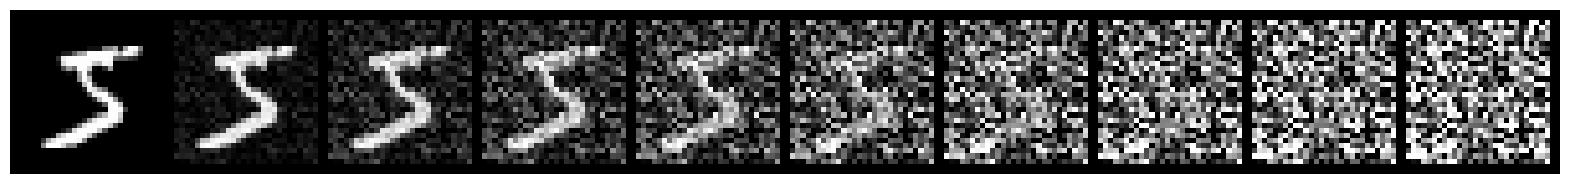

In [6]:
x0b = x0.repeat(10, 1, 1, 1)
t = torch.linspace(0, T, 10)
eps_b = torch.randn(1, 1, 28, 28).repeat(10, 1, 1, 1)  # one noise -> one line

r = q_sample(x0b, t.reshape(-1, 1, 1, 1), eps_b)

plt.figure(figsize=(20, 3))
plt.imshow(make_grid(r, nrow=10, normalize=True, value_range=(-1, 1)).permute(1, 2, 0))
plt.axis("off")
plt.show()

In [7]:
def timestep_embedding(t, dim):
    # t: [B] -> [B, dim]
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t[:, None].float() * freqs[None, :]  # [B, half]
    return torch.cat([args.sin(), args.cos()], dim=-1)  # [B, dim]


class TinyDenoiser(nn.Module):
    def __init__(self, channels=64, time_dim=64):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, channels),
        )
        self.conv_in = nn.Conv2d(1, channels, 3, padding=1)
        self.conv_mid = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv_out = nn.Conv2d(channels, 1, 3, padding=1)
        self.act = nn.SiLU()

    def forward(self, x, t):
        # x: [B, 1, 28, 28], t: [B]
        emb = self.time_mlp(timestep_embedding(t, self.time_dim))  # [B, C]
        h = self.conv_in(x) + emb[:, :, None, None]
        h = self.act(h)
        h = self.act(self.conv_mid(h))
        return self.conv_out(h)

An untrained net outputs roughly 0. So its loss is:

```-
MSE(0, v) = E[v²]
```


In [8]:
def target(x0, noise):
    return noise - x0


def loss_fn(model, x0):
    b = x0.shape[0]
    t = torch.rand(b) * T  # continuous, not randint
    noise = torch.randn_like(x0)
    x_s = q_sample(x0, t.reshape(-1, 1, 1, 1), noise)
    return F.mse_loss(model(x_s, t), target(x0, noise))


loader = DataLoader(dataset, batch_size=128, shuffle=True)
images, _ = next(iter(loader))

torch.manual_seed(0)
m = TinyDenoiser()
print("init loss:", torch.stack([loss_fn(m, images) for _ in range(20)]).mean().item())
print("E[v^2]   :", target(images, torch.randn_like(images)).square().mean().item())

init loss: 2.0273633003234863
E[v^2]   : 1.930161952972412


In [9]:
device = "cuda"
model = TinyDenoiser().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-4)
loader = DataLoader(
    dataset, batch_size=128, shuffle=True, num_workers=4, drop_last=True
)

for epoch in range(3):
    start, total, n = time.time(), 0.0, 0
    for images, _ in loader:
        x0 = images.to(device)
        t = torch.rand(x0.shape[0], device=device) * T
        noise = torch.randn_like(x0)
        x_s = q_sample(x0, t.reshape(-1, 1, 1, 1), noise)

        loss = F.mse_loss(model(x_s, t), target(x0, noise))

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()
        n += 1
    print(f"epoch {epoch}  loss {total / n:.4f}  {time.time() - start:.1f}s")

epoch 0  loss 0.6679  3.9s
epoch 1  loss 0.3839  3.8s
epoch 2  loss 0.3261  3.7s


range [-1.32, 1.54]  mean -0.813  std 0.494


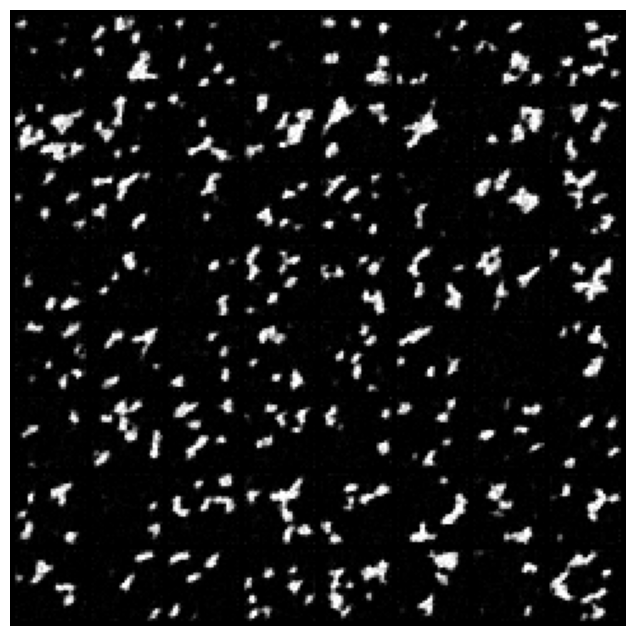

In [10]:
@torch.no_grad()
def sample(model, n=64, steps=50, x=None):
    ts = torch.linspace(T, 0, steps + 1, device=device)
    x = torch.randn(n, 1, 28, 28, device=device) if x is None else x
    for i in range(steps):
        t = ts[i].expand(x.shape[0])
        ds = (ts[i + 1] - ts[i]) / T
        x = x + ds * model(x, t)
    return x


s = sample(model, 64, steps=50)
print(f"range [{s.min():.2f}, {s.max():.2f}]  mean {s.mean():.3f}  std {s.std():.3f}")

plt.figure(figsize=(8, 8))
plt.imshow(
    make_grid(s.cpu(), nrow=8, normalize=True, value_range=(-1, 1)).permute(1, 2, 0)
)
plt.axis("off")
plt.show()

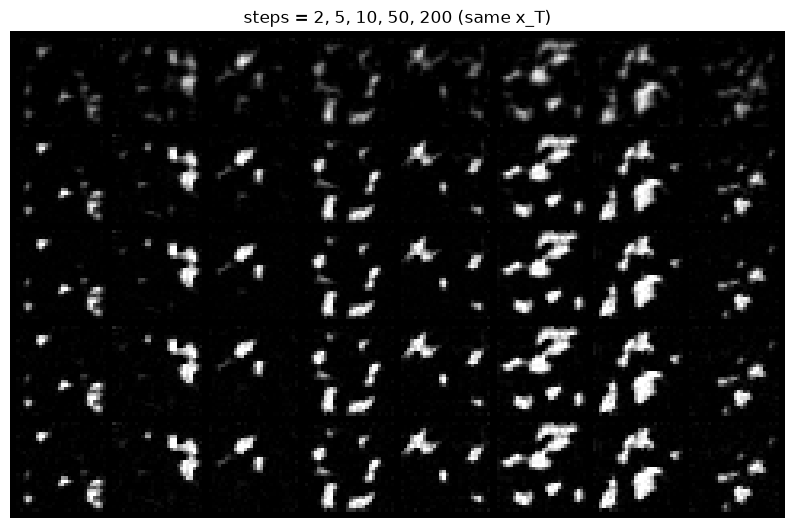

In [11]:
# the payoff: a straight path is cheap to follow with big steps
torch.manual_seed(0)
x_T = torch.randn(8, 1, 28, 28, device=device)

rows = [sample(model, steps=k, x=x_T.clone()) for k in (2, 5, 10, 50, 200)]

plt.figure(figsize=(10, 7))
plt.imshow(
    make_grid(
        torch.cat(rows).cpu(), nrow=8, normalize=True, value_range=(-1, 1)
    ).permute(1, 2, 0)
)
plt.axis("off")
plt.title("steps = 2, 5, 10, 50, 200 (same x_T)")
plt.show()

### Explaination


Fair. Here it is in that form.

Forward, same as you know:

    x_s = (1-s)·x0 + s·e

Write it at two times, `s` and `s'`. Same `x0`, same `e` — only `s` changes:

    x_s  = (1-s)·x0  + s·e
    x_s' = (1-s')·x0 + s'·e

Subtract:

    x_s' - x_s = (s - s')·x0 + (s' - s)·e
               = (s' - s)·(e - x0)
               = (s' - s)·v

So:

    x_s' = x_s + (s' - s)·v

That's the sampler. `s' < s` so the coefficient is negative, and you walk from `s=1` down to `s=0`.


<div style="display:flex; gap:12px; align-items:flex-start">
<div style="flex:1">

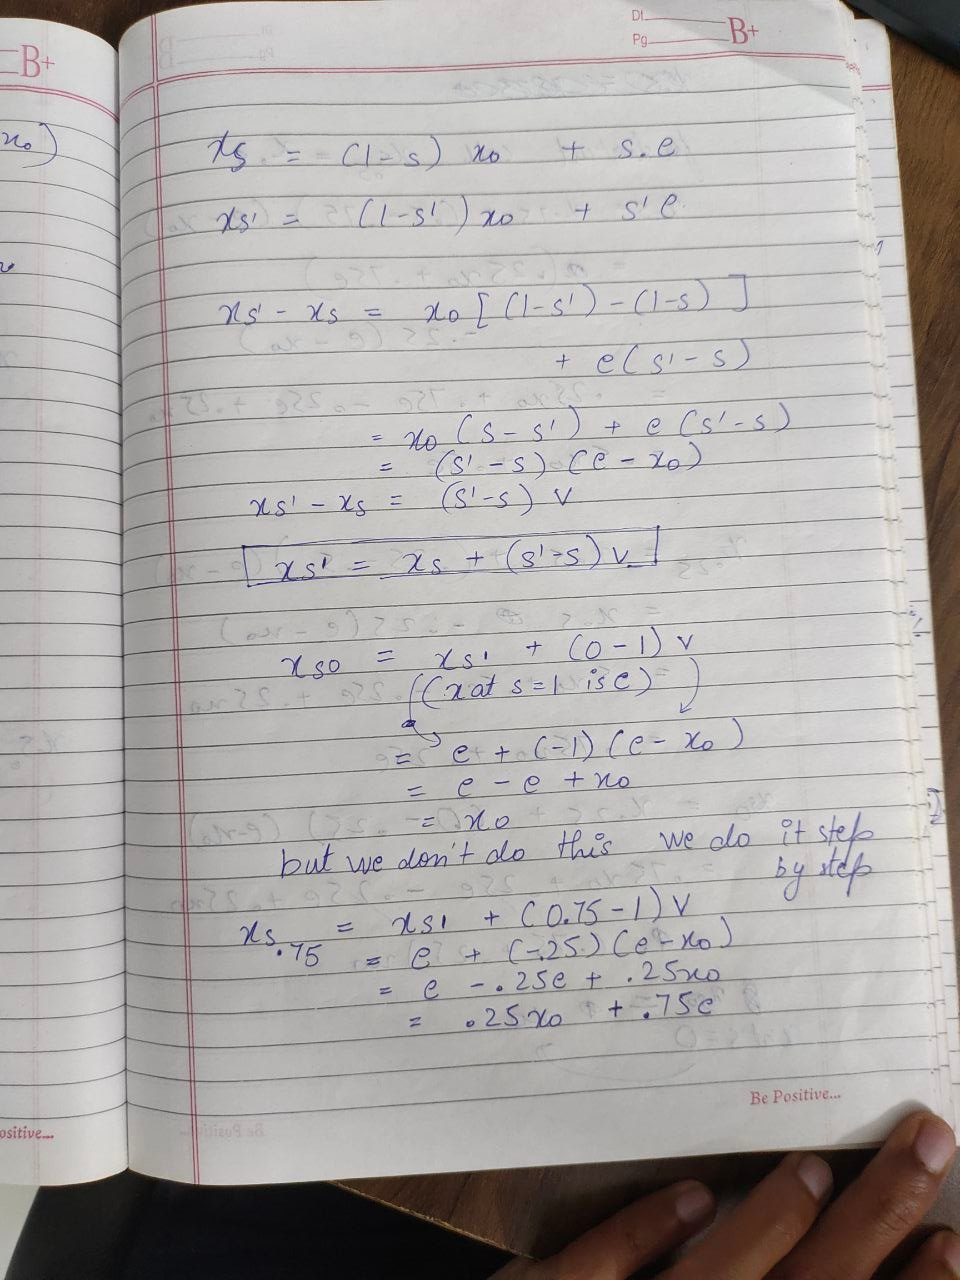

</div>
<div style="flex:1">

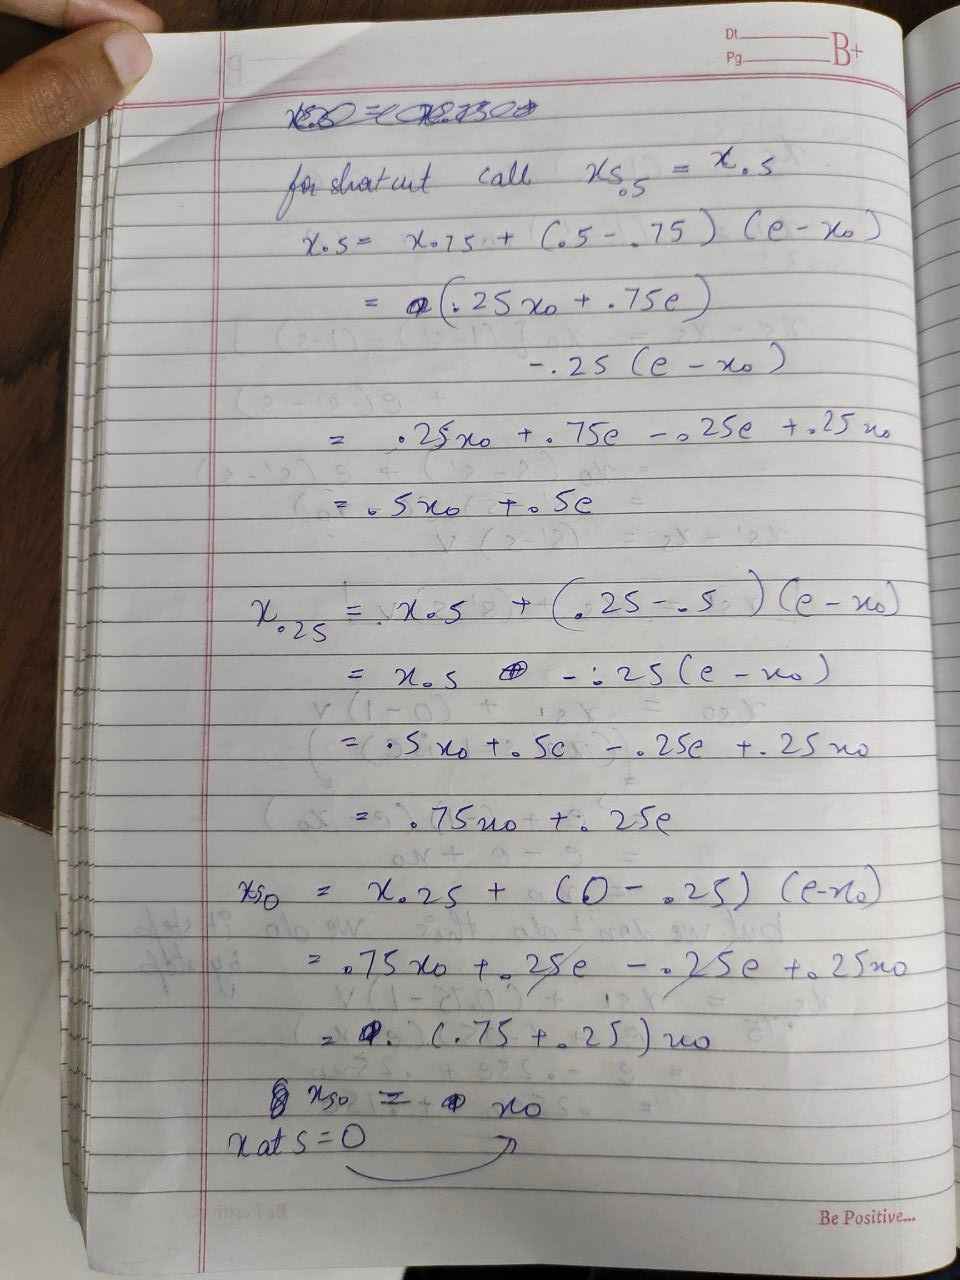

</div>
</div>


In [12]:
def q_sample_direct(x0, s, noise):
    return (1 - s) * x0 + s * noise


steps = 4
grid = torch.linspace(1, 0, steps + 1)
print(f"{grid=}")
x0 = torch.randn(5, 1)
e = torch.randn_like(x0)
v = target(x0, e)  # the exact velocity

x = q_sample_direct(x0, 1.0, e)  # start at s=1, which is just e
for s, s_next in zip(grid[:-1], grid[1:]):
    x = x + (s_next - s) * v

print(torch.allclose(x, x0, atol=1e-6))  # lands exactly on x0, any number of steps


grid=tensor([1.0000, 0.7500, 0.5000, 0.2500, 0.0000])
True


In [13]:
steps = 4
grid = torch.linspace(T, 0, steps + 1)
print(f"{grid=}")
x0 = torch.randn(5, 1)
e = torch.randn_like(x0)
v = target(x0, e)  # the exact velocity

x = q_sample(x0, T, e)  # start at s=1, which is just e
for t, t_next in zip(grid[:-1], grid[1:]):
    x = x + (s_of(t_next) - s_of(t)) * v

print(torch.allclose(x, x0, atol=1e-6))  # lands exactly on x0, any number of steps


grid=tensor([1000.,  750.,  500.,  250.,    0.])
True


### why don't we directly predict x0 from x1 ie eps

**Why it gives a blur.** The model outputs `E[·]`, so that one-step answer is `E[x0 | x1]`. But `x1 = e`, and `e` is independent of `x0`. So:

    E[x0 | x1] = E[x0] = the dataset mean

Same answer for every noise you feed it. Not a training failure — there's no information in `x1` about _which_ x0, so the best possible answer is the average one.

**What the small step changes.** Step from `s=1` to `s=0.99`. Now

    x_0.99 = 0.01·x0 + 0.99·e

That `0.01·x0` is no longer independent of `x0` — the point has _leaned_ slightly toward your answer. Ask the model again and its average is now taken over a smaller set of candidates. Lean, re-average, lean, re-average; the set narrows each time until it's one sample.

So: `v` is exactly right at every point. It's just that **the average of many destinations isn't any one destination**, and the only way to stop averaging is to commit a little before asking again.
